In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
inventory = pd.read_csv(
    "../data/processed/inventory_cleaned.csv"
)

inventory.head()

,Product ID,Store ID,Stock Levels,Supplier Lead Time (days),Stockout Frequency,Reorder Point,Expiry Date,Warehouse Capacity,Order Fulfillment Time (days)
0,9286,16,700,10,14,132,2024-01-15,1052,6
1,2605,60,82,11,1,127,2024-12-16,1262,9
2,2859,55,145,25,14,192,2024-04-30,1457,12
3,2374,24,151,17,6,19,2024-12-16,2944,3
4,7678,5,714,12,2,21,2024-08-05,3739,7


In [4]:
inventory.describe()

,Product ID,Store ID,Stock Levels,Supplier Lead Time (days),Stockout Frequency,Reorder Point,Warehouse Capacity,Order Fulfillment Time (days)
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5534.614600,50.192900,502.119000,15.050000,9.495300,104.617500,2998.757400,7.544600
std,2619.330826,28.656605,288.888252,8.446362,5.774384,54.883156,1158.289745,4.036637
min,1000.000000,1.000000,0.000000,1.000000,0.000000,10.000000,1000.000000,1.000000
25%,3235.750000,25.000000,253.000000,8.000000,5.000000,57.000000,1971.500000,4.000000
50%,5559.000000,50.000000,498.000000,15.000000,9.000000,105.000000,3016.000000,7.000000
75%,7841.250000,75.000000,751.000000,22.000000,15.000000,152.000000,4011.000000,11.000000
max,9998.000000,99.000000,999.000000,29.000000,19.000000,199.000000,4999.000000,14.000000


Low Stock Products

In [5]:
low_stock = inventory[
    inventory["Stock Levels"]
    < inventory["Reorder Point"]
]

print("Low Stock Products:", len(low_stock))

Low Stock Products: 1050


Stockout risk products

In [6]:
high_risk = inventory[
    inventory["Stockout Frequency"] > 15
]

print("High Risk Products:", len(high_risk))

High Risk Products: 2000


Warehouse Utilization

In [7]:
inventory["Warehouse Utilization"] = (
    inventory["Stock Levels"]
    /
    inventory["Warehouse Capacity"]
)

inventory["Warehouse Utilization"].describe()

count    10000.000000
mean         0.202837
std          0.164037
min          0.000000
25%          0.083720
50%          0.166810
75%          0.269587
max          0.995015
Name: Warehouse Utilization, dtype: float64

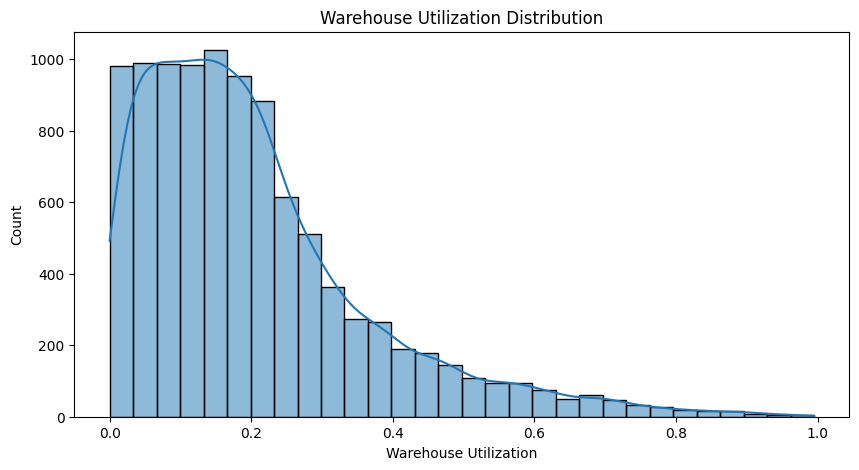

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    inventory["Warehouse Utilization"],
    bins=30,
    kde=True
)

plt.title("Warehouse Utilization Distribution")

plt.savefig(
    "../reports/figures/inventory/warehouse_utilization_distribution.png",
    bbox_inches="tight"
)

plt.show()

Inventry alert flag

In [8]:
inventory["Inventory Alert"] = (
    inventory["Stock Levels"]
    < inventory["Reorder Point"]
).astype(int)

inventory["Inventory Alert"].value_counts()

Inventory Alert
0    8950
1    1050
Name: count, dtype: int64

In [14]:
inventory["Inventory Alert"].value_counts(normalize=True)

Inventory Alert
0    0.895
1    0.105
Name: proportion, dtype: float64

Products below reorder point

In [9]:
low_stock = inventory[
    inventory["Stock Levels"]
    < inventory["Reorder Point"]
]

print("Products needing reorder:")
print(len(low_stock))

Products needing reorder:
1050


In [10]:
high_risk = inventory[
    inventory["Stockout Frequency"] > 15
]

print("High stockout risk products:")
print(len(high_risk))

High stockout risk products:
2000


safety stck calculation

In [15]:
inventory["Safety Stock"] = (
    1.65 *
    inventory["Stockout Frequency"] *
    (inventory["Supplier Lead Time (days)"] ** 0.5)
)

Recommended Reorder Point

In [16]:
inventory["Recommended Reorder Point"] = (
    inventory["Reorder Point"]
    + inventory["Safety Stock"]
)

In [17]:
inventory[
    [
        "Stock Levels",
        "Reorder Point",
        "Safety Stock",
        "Recommended Reorder Point"
    ]
].head()

,Stock Levels,Reorder Point,Safety Stock,Recommended Reorder Point
0,700,132,73.048614,205.048614
1,82,127,5.472431,132.472431
2,145,192,115.500000,307.500000
3,151,19,40.818746,59.818746
4,714,21,11.431535,32.431535


saving Optimization result

In [18]:
inventory.to_csv(
    "../data/processed/inventory_optimized.csv",
    index=False
)

Merging demand forecast

In [19]:
forecast = pd.read_csv(
    "../data/processed/demand_forecast.csv"
)

In [20]:
forecast.columns

Index(['Product ID', 'Date', 'Store ID', 'Sales Quantity', 'Price',
       'Promotions', 'Seasonality Factors', 'External Factors', 'Demand Trend',
       'Customer Segments', 'Forecasted Demand'],
      dtype='object')

In [21]:
inventory_final = inventory.merge(
    forecast[
        [
            "Product ID",
            "Store ID",
            "Forecasted Demand"
        ]
    ],
    on=[
        "Product ID",
        "Store ID"
    ],
    how="left"
)

In [22]:
inventory_final.shape

(10001, 14)

In [23]:
inventory_final.head()

,Product ID,Store ID,Stock Levels,Supplier Lead Time (days),Stockout Frequency,Reorder Point,Expiry Date,Warehouse Capacity,Order Fulfillment Time (days),Warehouse Utilization,Inventory Alert,Safety Stock,Recommended Reorder Point,Forecasted Demand
0,9286,16,700,10,14,132,2024-01-15,1052,6,0.665399,0,73.048614,205.048614,NaN
1,2605,60,82,11,1,127,2024-12-16,1262,9,0.064976,1,5.472431,132.472431,NaN
2,2859,55,145,25,14,192,2024-04-30,1457,12,0.099520,1,115.500000,307.500000,NaN
3,2374,24,151,17,6,19,2024-12-16,2944,3,0.051291,0,40.818746,59.818746,NaN
4,7678,5,714,12,2,21,2024-08-05,3739,7,0.190960,0,11.431535,32.431535,NaN


create a better reorder calculation

Reorder Point =
(Forecasted Daily Demand × Lead Time)
+ Safety Stock

In [24]:
inventory_final["Demand Based Reorder Point"] = (
    inventory_final["Forecasted Demand"]
    *
    inventory_final["Supplier Lead Time (days)"]
    +
    inventory_final["Safety Stock"]
)

Final inventory status

In [25]:
def inventory_status(row):

    if row["Stock Levels"] == 0:
        return "Stockout"

    elif row["Stock Levels"] < row["Demand Based Reorder Point"]:
        return "Reorder Required"

    elif row["Stock Levels"] > row["Warehouse Capacity"] * 0.8:
        return "Overstock"

    else:
        return "Normal"


inventory_final["Inventory Status"] = (
    inventory_final.apply(
        inventory_status,
        axis=1
    )
)

alert checks

In [26]:
inventory_final["Inventory Status"].value_counts()

Inventory Status
Normal              9813
Reorder Required     113
Overstock             69
Stockout               6
Name: count, dtype: int64

In [27]:
inventory_final.to_csv(
    "../data/processed/final_inventory_optimization.csv",
    index=False
)